<a href="https://colab.research.google.com/github/hridibazaman03/220142_CNN_RPS/blob/main/220142_CNN_RPS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import random
import zipfile
import shutil
import requests
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


In [ ]:
REPO_URL = "https://github.com/hridibazaman03/220142_CNN_RPS.git"
REPO_DIR = "/content/220142_CNN_RPS"

if os.path.exists(REPO_DIR):
    shutil.rmtree(REPO_DIR)

!git clone {REPO_URL}

print("Repository cloned successfully!")
print(os.listdir(REPO_DIR))

Cloning into '220142_CNN_RPS'...
remote: Enumerating objects: 56, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 56 (delta 12), reused 4 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (56/56), 42.93 MiB | 14.43 MiB/s, done.
Resolving deltas: 100% (12/12), done.
Repository cloned successfully!
['dataset', 'model', 'README.md', '220142_CNN_RPS.ipynb', '.git']


In [ ]:
RPS_URL = "https://storage.googleapis.com/learning-datasets/rps.zip"
RPS_ZIP = "/content/rps.zip"
RPS_DIR = "/content/rps"

# Download automatically
response = requests.get(RPS_URL)

with open(RPS_ZIP, "wb") as f:
    f.write(response.content)

print("Standard RPS dataset downloaded automatically.")

Standard RPS dataset downloaded automatically.


In [ ]:
if os.path.exists(RPS_DIR):
    shutil.rmtree(RPS_DIR)

with zipfile.ZipFile(RPS_ZIP, "r") as zip_ref:
    zip_ref.extractall("/content")

print("RPS dataset extracted.")

RPS dataset extracted.


In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 64

mean = [0.5, 0.5, 0.5]
std = [0.5, 0.5, 0.5]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [ ]:
from torchvision import datasets, transforms

train_full = datasets.ImageFolder(
    root="/content/rps",
    transform=train_transform
)

print("Dataset loaded using torchvision.datasets.ImageFolder")
print("Classes:", train_full.classes)
print("Total images:", len(train_full))

Dataset loaded using torchvision.datasets.ImageFolder
Classes: ['paper', 'rock', 'scissors']
Total images: 2520


In [ ]:
from torch.utils.data import random_split

# Create a dataset without augmentation for evaluation
full_test_dataset = datasets.ImageFolder(
    root="/content/rps",
    transform=test_transform
)

# Calculate split sizes
train_size = int(0.8 * len(full_test_dataset))
test_size = len(full_test_dataset) - train_size

# Split dataset
train_dataset, test_dataset = random_split(
    full_test_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Classes:", full_test_dataset.classes)
print("Total images:", len(full_test_dataset))
print("Training images:", len(train_dataset))
print("Test images:", len(test_dataset))

Classes: ['paper', 'rock', 'scissors']
Total images: 2520
Training images: 2016
Test images: 504


In [ ]:
train_size = int(0.8 * len(train_full))
val_size = len(train_full) - train_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(
    train_full,
    [train_size, val_size],
    generator=generator
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

Training images: 2016
Validation images: 504
Test images: 504


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("DataLoaders created successfully.")

DataLoaders created successfully.


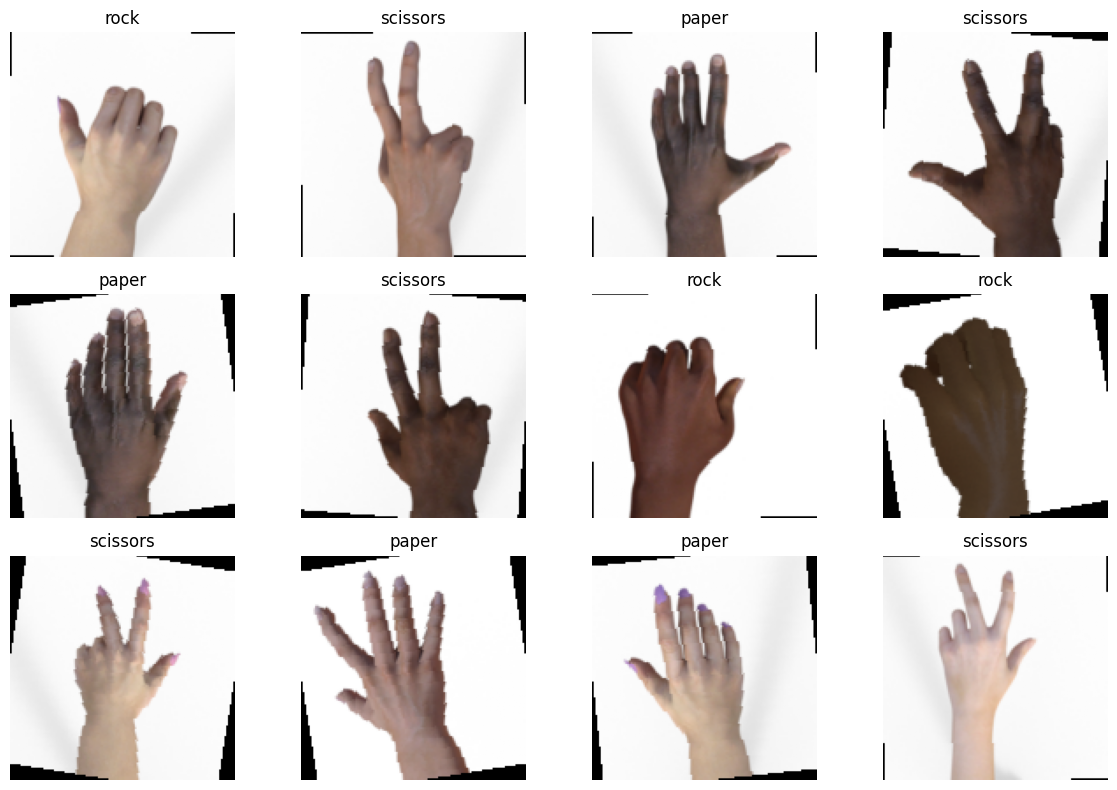

In [ ]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))

for i in range(12):
    image = images[i].permute(1, 2, 0).numpy()

    # Undo normalization
    image = image * 0.5 + 0.5
    image = np.clip(image, 0, 1)

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(train_full.classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.features = nn.Sequential(

            # First convolution block
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Second convolution block
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Third convolution block
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.pool = nn.AdaptiveAvgPool2d((4, 4))

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128, 3)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.pool(x)

        x = self.classifier(x)

        return x

In [ ]:
model = CNN().to(device)

print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=(4, 4))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=3, bias=True)
  )
)


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy

In [ ]:
def evaluate(model, loader, criterion):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy

In [ ]:
NUM_EPOCHS = 10

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_accuracy = 0.0

MODEL_DIR = os.path.join(REPO_DIR, "model")

os.makedirs(MODEL_DIR, exist_ok=True)

best_model_path = os.path.join(
    MODEL_DIR,
    "220142.pth"
)

for epoch in range(NUM_EPOCHS):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_accuracy = evaluate(
        model,
        val_loader,
        criterion
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            best_model_path
        )

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}%"
    )

print("\nTraining completed.")
print("Best validation accuracy:", best_val_accuracy)
print("Model saved at:", best_model_path)

Epoch [1/10] Train Loss: 1.0683 Train Acc: 39.63% Val Loss: 0.9063 Val Acc: 68.65%
Epoch [2/10] Train Loss: 0.5469 Train Acc: 77.78% Val Loss: 0.2356 Val Acc: 96.03%
Epoch [3/10] Train Loss: 0.1741 Train Acc: 94.99% Val Loss: 0.1033 Val Acc: 98.61%
Epoch [4/10] Train Loss: 0.1095 Train Acc: 97.02% Val Loss: 0.0910 Val Acc: 98.41%
Epoch [5/10] Train Loss: 0.0576 Train Acc: 98.46% Val Loss: 0.0913 Val Acc: 96.63%
Epoch [6/10] Train Loss: 0.0721 Train Acc: 98.16% Val Loss: 0.0607 Val Acc: 98.61%
Epoch [7/10] Train Loss: 0.0399 Train Acc: 98.81% Val Loss: 0.0405 Val Acc: 98.61%
Epoch [8/10] Train Loss: 0.0304 Train Acc: 99.06% Val Loss: 0.0474 Val Acc: 98.61%
Epoch [9/10] Train Loss: 0.0269 Train Acc: 99.31% Val Loss: 0.0289 Val Acc: 99.40%
Epoch [10/10] Train Loss: 0.0227 Train Acc: 99.26% Val Loss: 0.0479 Val Acc: 98.61%

Training completed.
Best validation accuracy: 99.4047619047619
Model saved at: /content/220142_CNN_RPS/model/220142.pth


In [ ]:
model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


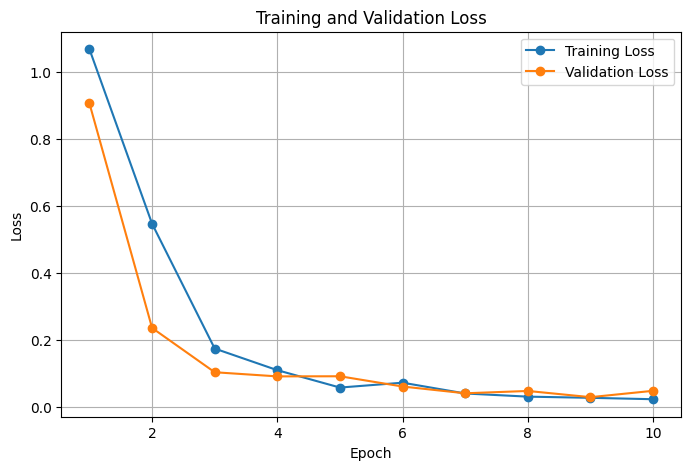

In [ ]:
epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

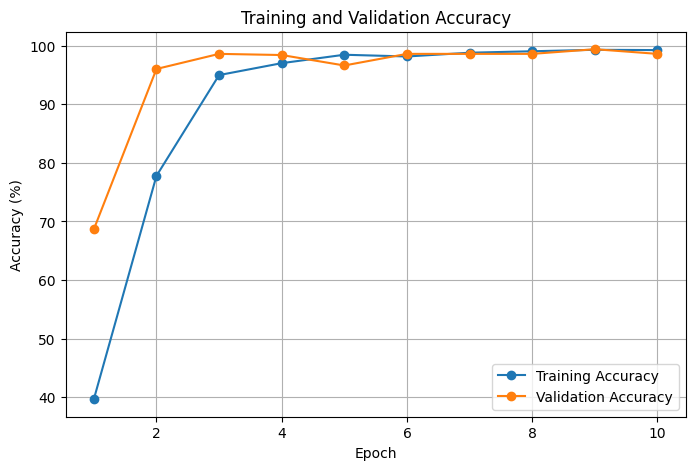

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_accuracies,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_accuracies,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
test_loss, test_accuracy = evaluate(
    model,
    test_loader,
    criterion
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.0335
Test Accuracy: 99.01%


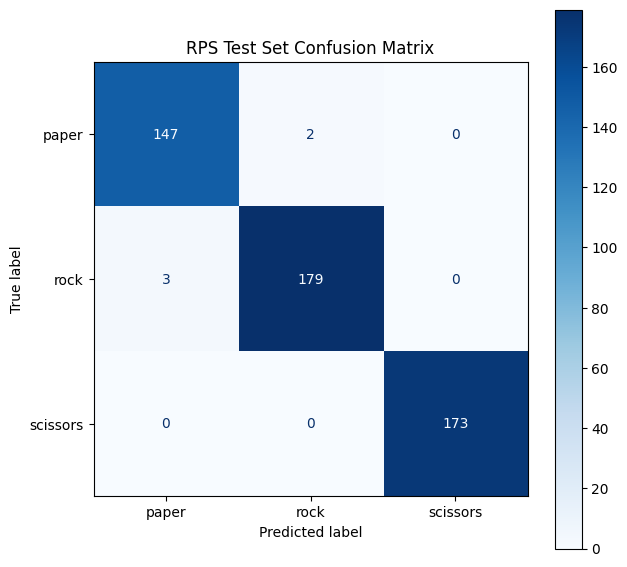

In [ ]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predictions = torch.max(outputs, 1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=full_test_dataset.classes
)

fig, ax = plt.subplots(figsize=(7, 7))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("RPS Test Set Confusion Matrix")

plt.show()

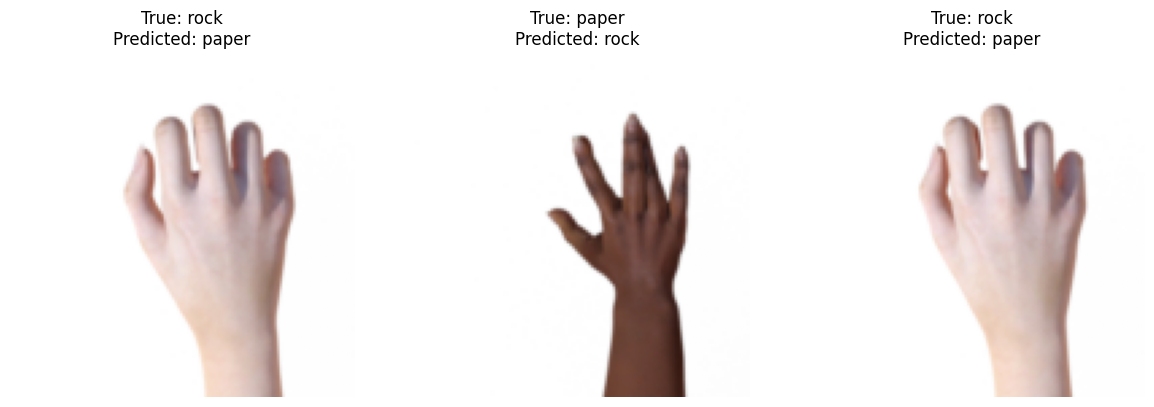

In [ ]:
model.eval()

wrong_images = []
wrong_labels = []
wrong_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels_device = labels.to(device)

        outputs = model(images)

        _, predictions = torch.max(outputs, 1)

        incorrect = predictions != labels_device

        for i in range(len(images)):

            if incorrect[i]:

                wrong_images.append(
                    images[i].cpu()
                )

                wrong_labels.append(
                    labels[i].item()
                )

                wrong_predictions.append(
                    predictions[i].item()
                )

if len(wrong_images) > 0:

    selected = random.sample(
        range(len(wrong_images)),
        min(3, len(wrong_images))
    )

    plt.figure(figsize=(12, 4))

    for plot_index, item_index in enumerate(selected):

        image = wrong_images[item_index]

        image = image.permute(1, 2, 0).numpy()

        image = image * 0.5 + 0.5

        image = np.clip(image, 0, 1)

        true_label = full_test_dataset.classes[
            wrong_labels[item_index]
        ]

        predicted_label = full_test_dataset.classes[
            wrong_predictions[item_index]
        ]

        plt.subplot(1, 3, plot_index + 1)

        plt.imshow(image)

        plt.title(
            f"True: {true_label}\n"
            f"Predicted: {predicted_label}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

else:

    print("No incorrect predictions found!")

In [ ]:
CUSTOM_DIR = os.path.join(
    REPO_DIR,
    "dataset"
)

custom_images = [
    file for file in os.listdir(CUSTOM_DIR)
    if file.lower().endswith(
        (".jpg", ".jpeg", ".png")
    )
]

custom_images.sort()

print("Custom images found:", len(custom_images))

for image_name in custom_images:
    print(image_name)

Custom images found: 10
paper1.jpg
paper2.jpg
paper3.jpg
rock1.jpg
rock2.jpg
rock3.jpg
scissors1.jpg
scissors2.jpg
scissors3.jpg
scissors4.jpg


In [ ]:
from PIL import Image
import os
import pandas as pd

metadata = []

for image_name in custom_images:
    image_path = os.path.join(CUSTOM_DIR, image_name)

    with Image.open(image_path) as img:
        metadata.append({
            "Filename": image_name,
            "Format": img.format,
            "Width": img.width,
            "Height": img.height,
            "Color Mode": img.mode,
            "File Size (bytes)": os.path.getsize(image_path)
        })

metadata_df = pd.DataFrame(metadata)

display(metadata_df)

,Filename,Format,Width,Height,Color Mode,File Size (bytes)
0,paper1.jpg,JPEG,763,972,RGB,95151
1,paper2.jpg,JPEG,660,984,RGB,89554
2,paper3.jpg,JPEG,842,985,RGB,89067
3,rock1.jpg,JPEG,774,963,RGB,84695
4,rock2.jpg,JPEG,677,661,RGB,54155
5,rock3.jpg,JPEG,607,685,RGB,35673
6,scissors1.jpg,JPEG,621,1150,RGB,72424
7,scissors2.jpg,JPEG,759,1117,RGB,98657
8,scissors3.jpg,JPEG,859,1185,RGB,105763
9,scissors4.jpg,JPEG,641,1179,RGB,76759


In [ ]:
def predict_custom_image(image_path):

    image = Image.open(image_path).convert("RGB")

    original_image = image.copy()

    image_tensor = test_transform(image)

    image_tensor = image_tensor.unsqueeze(0)

    image_tensor = image_tensor.to(device)

    model.eval()

    with torch.no_grad():

        output = model(image_tensor)

        probabilities = torch.softmax(
            output,
            dim=1
        )

        confidence, predicted_class = torch.max(
            probabilities,
            1
        )

    predicted_class_name = full_test_dataset.classes[
        predicted_class.item()
    ]

    confidence_percentage = (
        confidence.item() * 100
    )

    return (
        original_image,
        predicted_class_name,
        confidence_percentage
    )

In [ ]:
prediction_results = []

for image_name in custom_images:

    image_path = os.path.join(
        CUSTOM_DIR,
        image_name
    )

    image, prediction, confidence = (
        predict_custom_image(image_path)
    )

    prediction_results.append({
        "filename": image_name,
        "image": image,
        "prediction": prediction,
        "confidence": confidence
    })

    print(
        f"{image_name} -> "
        f"{prediction} "
        f"({confidence:.2f}%)"
    )

paper1.jpg -> paper (99.79%)
paper2.jpg -> rock (70.35%)
paper3.jpg -> scissors (79.73%)
rock1.jpg -> rock (71.47%)
rock2.jpg -> rock (99.86%)
rock3.jpg -> rock (99.92%)
scissors1.jpg -> scissors (99.37%)
scissors2.jpg -> scissors (53.43%)
scissors3.jpg -> scissors (97.75%)
scissors4.jpg -> scissors (77.42%)


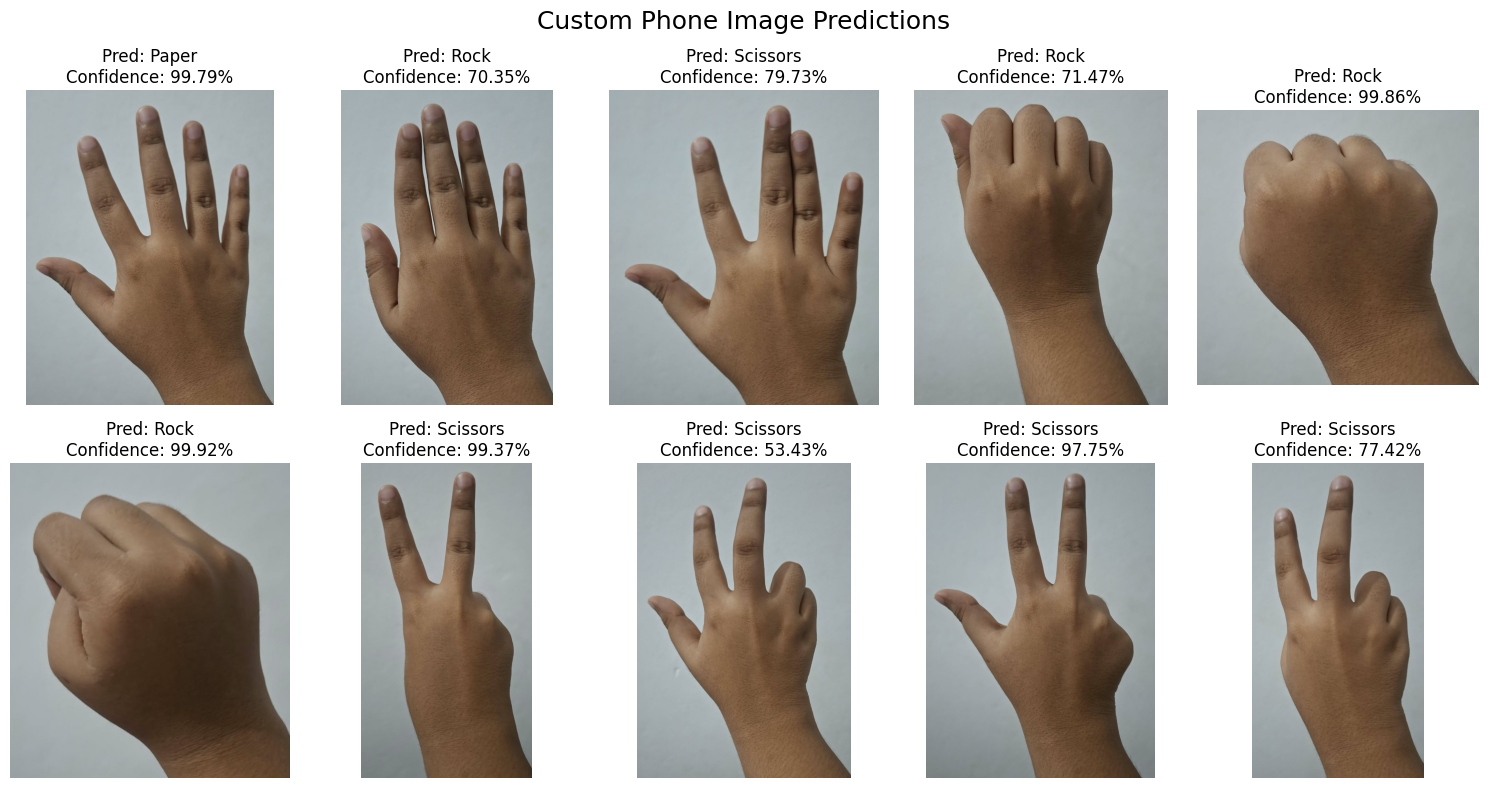

In [ ]:
num_images = len(prediction_results)

cols = 5
rows = int(np.ceil(num_images / cols))

plt.figure(figsize=(15, rows * 4))

for i, result in enumerate(prediction_results):

    plt.subplot(rows, cols, i + 1)

    plt.imshow(result["image"])

    plt.title(
        f"Pred: {result['prediction'].capitalize()}\n"
        f"Confidence: {result['confidence']:.2f}%"
    )

    plt.axis("off")

plt.suptitle(
    "Custom Phone Image Predictions",
    fontsize=18
)

plt.tight_layout()

plt.show()

In [ ]:
correct_custom = 0

for result in prediction_results:

    filename = result["filename"].lower()
    prediction = result["prediction"].lower()

    if filename.startswith(prediction):
        correct_custom += 1

custom_accuracy = (
    correct_custom / len(prediction_results)
) * 100

print(
    f"Custom Image Accuracy: "
    f"{custom_accuracy:.2f}%"
)

Custom Image Accuracy: 80.00%
